In [9]:
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')) + '/..')

from XSpect import Pipeline
import numpy as npz
import matplotlib.pyplot as plt

p = Pipeline.from_yaml('mfx101609126_static_rixs.yaml')
p.run(cores=4, batch_size=500)

run = p.analyzed_runs[0]
print(f'Runs processed: {len(p.analyzed_runs)}')
print(f'Energy bins: {len(run.ccm_energies)}')
print(f'Total shots: {run.epix_energy_bincount.sum():.0f}')
print(f'Avg shots/bin: {run.epix_energy_bincount.mean():.0f}')

ConfigValidationError: Config file not found: mfx101609126_static_rixs.yaml

In [2]:
# RIXS plane: incident energy (DCCM) vs emission pixel
rixs = run.epix_energy_binned_ROI_1  # (n_energy x n_emission_pixels)
incident_energy = run.ccm_energies * 1000  # keV -> eV

print(f'RIXS plane shape: {rixs.shape}')
print(f'Incident energy range: {incident_energy[0]:.1f} - {incident_energy[-1]:.1f} eV')

RIXS plane shape: (71, 300)
Incident energy range: 7095.0 - 8105.2 eV


In [ ]:
# --- Detector ROI diagnostic ---
# epix_reduced: sum of all ADU-filtered xray frames (60 rows x 300 cols).
# Left panel: 2D image with the current spatial ROI marked (red dashes).
# Right panel: row projection (sum over emission axis) showing where signal
#              is concentrated in the cross-dispersion direction.
# Adjust rois in the YAML if the red band does not cover the signal peak.

img = run.epix_reduced          # shape (60, 300)
roi_rows = [0, 60]              # must match rois: [[0, 60]] in the YAML

fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                         gridspec_kw={'width_ratios': [3, 1]})

# 2D image
ax = axes[0]
im = ax.imshow(img, aspect='auto', origin='lower',
               extent=[0, img.shape[1], 0, img.shape[0]],
               cmap='viridis')
plt.colorbar(im, ax=ax, label='Counts')
ax.axhline(roi_rows[0], color='red', ls='--', lw=1.5, label=f'ROI y={roi_rows[0]}')
ax.axhline(roi_rows[1], color='red', ls='--', lw=1.5, label=f'ROI y={roi_rows[1]}')
ax.set_xlabel('Emission pixel (col)')
ax.set_ylabel('Cross-dispersion (row)')
ax.set_title('Summed xray frames — run 97')
ax.legend(fontsize=8)

# Row projection
ax2 = axes[1]
row_proj = img.sum(axis=1)   # sum over emission axis → signal vs row
ax2.plot(row_proj, np.arange(len(row_proj)))
ax2.axhline(roi_rows[0], color='red', ls='--', lw=1.5)
ax2.axhline(roi_rows[1], color='red', ls='--', lw=1.5)
ax2.set_xlabel('Counts')
ax2.set_ylabel('Cross-dispersion (row)')
ax2.set_title('Row projection')

plt.tight_layout()
plt.show()


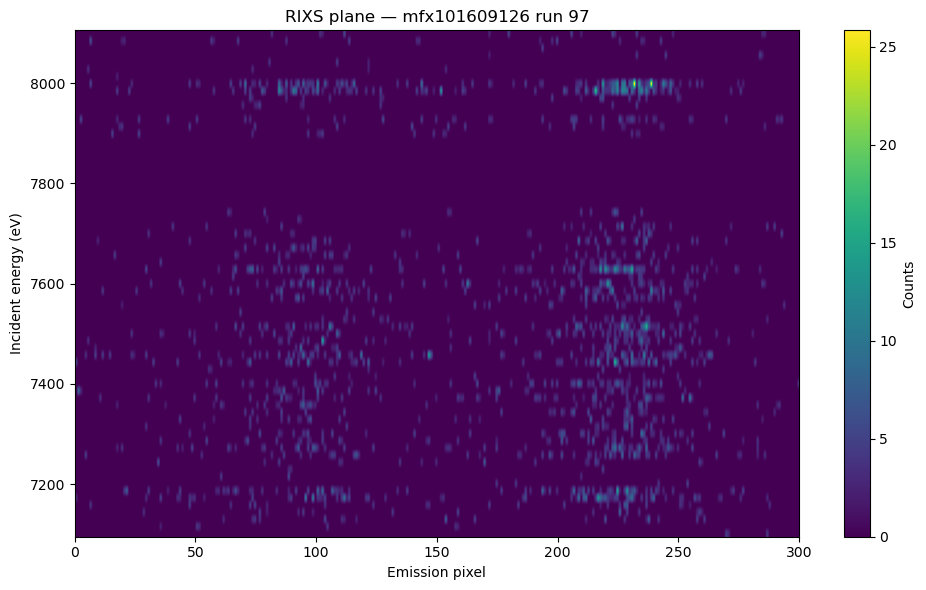

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    rixs,
    aspect='auto',
    origin='lower',
    extent=[0, rixs.shape[1], incident_energy[0], incident_energy[-1]],
    cmap='viridis',
)
cbar = plt.colorbar(im, ax=ax, label='Counts')
ax.set_xlabel('Emission pixel')
ax.set_ylabel('Incident energy (eV)')
ax.set_title('RIXS plane — mfx101609126 run 97')
plt.tight_layout()
plt.show()

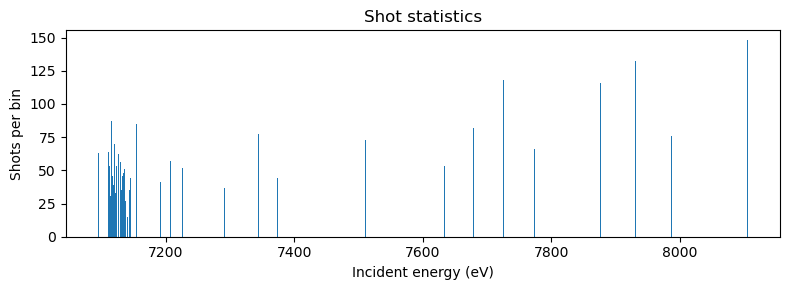

In [4]:
# Shot statistics per incident energy bin
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(incident_energy, run.epix_energy_bincount, width=np.median(np.diff(incident_energy)) * 0.8)
ax.set_xlabel('Incident energy (eV)')
ax.set_ylabel('Shots per bin')
ax.set_title('Shot statistics')
plt.tight_layout()
plt.show()